## 1. Importing libraries

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import zscore, skew
import seaborn as sns
import matplotlib.pyplot as plt
import sys
sys.path.append("../scripts")
from outlier_utils import print_outliers

## 2. Data Loading 

In [3]:
df = pd.read_csv("../data/kenya.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


## 3. Adding column & Date Parsing

In [4]:
# Add country column
df["Country"] = "Kenya"

# Convert YEAR + DOY to datetime
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract month
df["Month"] = df["Date"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1


- The dataset encodes dates using Year and Day-of-Year (DOY), which was converted into a proper datetime format to enable time-series analysis and seasonal interpretations.

## 4. Summary Statistics & Missing Values

In [5]:
# Replace sentinel values
df.replace(-999, np.nan, inplace=True)

# Duplicates
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()

Duplicate rows: 0


- No duplicates were found in any of the columns, which means every entry is unique

In [6]:
# Summary statistics
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


### Brief interpretation of the statistics
### 1. **General Observations**
- **Time span**: 4,108 days (~11.25 years), from 2015 through most of 2026.
- **DOY (Day of Year)** ranges from 1 to 366, confirming leap years are included (e.g., 2020, 2024).
---

### 2. **Temperature Variables (°C)**

| Variable | Mean | Min | Max | Interpretation |
|----------|------|-----|-----|----------------|
| **T2M** | 20.4 | 15.3 | 25.4 | Mild, semi-tropical or temperate climate; no freezing temperatures. |
| **T2M_MAX** | 27.8 | 18.9 | 34.3 | Hot days occur, but rare extremes above 34°C. |
| **T2M_MIN** | 14.7 | 9.0 | 18.8 | Nights are cool-to-mild; never freezing. |
| **T2M_RANGE** | 13.2 | 4.1 | 20.1 | Moderate diurnal variation; largest swings in dry/clear conditions. |

**Key insight**: The site has warm days and mild nights, with a mean diurnal range of ~13°C, typical of a **subtropical or semi-arid inland** location.

---

### 3. **Precipitation (PRECTOTCORR – mm/day)**
- **Mean**: 1.47 mm/day → ~536 mm/year (semi-arid to sub-humid).
- **Median**: 0.38 mm/day → most days have little or no rain.
- **Max**: 51.65 mm/day → rare but heavy rain events.
- **75th percentile**: 1.36 mm/day → even on rainier days, intensity is low.

**Interpretation**: Strongly **right-skewed** – dry conditions dominate, but occasional heavy downpours occur.

---

### 4. **Humidity & Moisture**

| Variable | Mean | Min–Max | Notes |
|----------|------|---------|-------|
| **RH2M (%)** | 65.8 | 28.4 – 91.1 | Moderate relative humidity; not persistently dry nor humid. |
| **QV2M (g/kg)** | 11.05 | 4.78 – 15.04 | Moderate specific humidity; corresponds to ~11 g water vapor per kg of air. |

**Interpretation**: Air is moderately moist; RH drops to ~28% on dry days, but specific humidity never extremely low, suggesting some moisture source.

---

### 5. **Wind Speed (m/s)**

| Variable | Mean | 75th %ile | Max | Interpretation |
|----------|------|-----------|-----|----------------|
| **WS2M** | 3.06 | 3.72 | 5.28 | Light to moderate mean winds. |
| **WS2M_MAX** | 4.38 | 5.09 | 7.59 | Gusts occasionally strong. |

**Interpretation**: Breezy but not extremely windy; max gusts ~7.6 m/s (~27 km/h).

---

### 6. **Atmospheric Pressure (PS – kPa)**
- **Mean**: 83.72 kPa  
- **Range**: 83.31 – 84.17 kPa  

Pressure is **lower than sea-level standard (~101.3 kPa)**, indicating the station is at **elevation (~1,600–1,800 meters)**.  
- Formula approximate: `Elevation (m) ≈ (101.3 - PS) * 100 / 1.2` → around **1,450–1,650 m** elevation.

---

## **Overall Climate Summary**
- **Climate type**: Warm temperate / subtropical highland or semi-arid.
- **Elevation**: ~1,500 m above sea level (inferred from PS).
- **Rainfall pattern**: Mostly dry; heavy rain infrequent.
- **Temperature**: No frost; comfortable mean annual temp ~20°C.
- **Diurnal range**: Moderate to large (~13°C).
- **Humidity**: Moderate; specific humidity relatively stable.

## 5. Missing values

In [7]:
# Missing values
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


- there are no null values, which makes our data interpretations and insights we draw from it more accurate since we dont miss anything

## 6. Outlier Detection

In [8]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

# Calculate z-scores
z_scores = np.abs(zscore(df[cols], nan_policy='omit'))

# Create named DataFrame for easier access
zscore_df = pd.DataFrame(
    z_scores, 
    columns=cols, 
    index=df.index
)

# FLAG the outliers (create a new column)
df['is_outlier'] = (zscore_df > 3).any(axis=1)  # ← THIS IS THE FLAG

# Report the counts
outliers = (z_scores > 3)
outlier_rows = df['is_outlier'].sum()
print("Outlier rows:", outlier_rows)
print(f"Percentage: {df['is_outlier'].mean()*100:.2f}%")

Outlier rows: 121
Percentage: 2.95%


- We have 121 rows with outlier values at one or more column, so now we check if they are erroneous values or seasonal extremities to make a decision whether to keep them or remove them.

### Check outliers by column

In [9]:
print_outliers(zscore_df, cols)

T2M: 8 outliers
T2M_MAX: 3 outliers
T2M_MIN: 9 outliers
PRECTOTCORR: 92 outliers
RH2M: 6 outliers
WS2M: 0 outliers
WS2M_MAX: 6 outliers


### Evaluating outliers

In [10]:
# 1. Physical possibility checks
impossible = df[
    (df["T2M_MAX"] < df["T2M_MIN"]) |  # Max < Min
    (df["RH2M"] > 100) |                # RH > 100%
    (df["RH2M"] < 0) |                  # RH < 0%
    (df["PRECTOTCORR"] < 0)             # Negative rain
]
print(f"Physically impossible rows: {len(impossible)}")

Physically impossible rows: 0


- We have no physically impossible rows, all values are within plausible ranges.

In [12]:
# 2. Check if outliers are seasonal
rain_outliers = df[zscore_df["PRECTOTCORR"] > 3] 
print("Precipitation outliers by month:")
print(rain_outliers["Month"].value_counts().sort_index())

Precipitation outliers by month:
Month
1      8
2      8
3     17
4     28
5      7
8      2
10     5
11     7
12    10
Name: count, dtype: int64


**Total daily precipitation (PRECTOTCORR)**

**Decision**: We will keep the precipitation outliers.

**Reasons:**
1. **Clear seasonal pattern confirms these are real weather events**
- **Peak in April (28 outliers)** and **March (17 outliers)** - likely the rainy season peak
- **December-March (8-17 outliers)** - wet season months
- **August only has 2 outliers** - dry season month with rare events
- This matches real climatology where heavy rain occurs in specific seasons

2. **The distribution makes meteorological sense**
- Outliers concentrate in months 3-4 (spring/early wet season)
- Very few in month 8 (dry season)
- The pattern suggests **convective storms**, not data errors

3. **The outlier percentage is reasonable**
- 92 / 4108 total days = **~2.2% of all days**
- This is a realistic frequency for heavy precipitation events

**What these outliers likely represent:**
- **April peak (28 events)** = End of dry season / start of wet season thunderstorms
- **March (17 events)** = Early season convection
- **These are scientifically important** for understanding extreme precipitation timing

In [18]:
min_temp_outliers = df[zscore_df["T2M_MIN"] > 3]
print("Minimun temprature outliers by month:")
print(min_temp_outliers["Month"].value_counts().sort_index())

temp_outliers = df[zscore_df["T2M"] > 3]
print("Temprature outliers by month:")
print(temp_outliers["Month"].value_counts().sort_index())

max_temp_outliers = df[zscore_df["T2M_MAX"] > 3]
print("Maximum Temprature outliers by month:")
print(temp_outliers["Month"].value_counts().sort_index())

Minimun temprature outliers by month:
Month
6    1
7    7
8    1
Name: count, dtype: int64
Temprature outliers by month:
Month
3    6
5    1
7    1
Name: count, dtype: int64
Maximum Temprature outliers by month:
Month
3    6
5    1
7    1
Name: count, dtype: int64


**Decision**: We will keep the temperature outliers.

**Minimum Temperature Outliers**
**Distribution:** June (1), July (7), August (1) = **9 total outliers**

**Reasons:**
These represent **unusually warm minimum temperatures** (since Z-score > 3 means higher than normal):

- **Peak in July (7 outliers)** - Midsummer nights staying unusually warm
- **Sporadic in June/August** - Shoulder months of summer
- **Only 9 days total (0.22% of data)** - Very rare events

**Mean and Max Temperature Outliers**

**Distribution:** March (6), May (1), July (1) = **8 total outliers**

**Reasons:**
These represent **unusually warm average temperatures**:

- **Peak in March (6 outliers)** - Early spring heat waves
- **Single events in May/July** - Occasional summer extremes. This pattern is valuable for climate studies (early heat waves can be more damaging to agriculture)
- **Only 8 days total (0.19% of data)** - Extremely rare

In [14]:
relative_humidity_outliers = df[zscore_df["RH2M"] > 3]
print("Relative humidity outliers by month:")
print(relative_humidity_outliers["Month"].value_counts().sort_index())

Relative humidity outliers by month:
Month
1    5
2    1
Name: count, dtype: int64


**Decision**: We will keep the humidity outliers.

**Relative Humidity Outliers (RH2M)**
**Distribution:** January(5), February(1)
   > RH values of 28-36% in January-February are characteristic of Kenya's dry season and were retained as valid observations. No data quality issues were identified.




In [17]:
max_daily_wind_speed_outliers = df[zscore_df["WS2M_MAX"] > 3]
print("Max daily wind speed outliers outliers by month:")
print(max_daily_wind_speed_outliers["Month"].value_counts().sort_index())

Max daily wind speed outliers outliers by month:
Month
1     2
2     1
4     1
5     1
12    1
Name: count, dtype: int64


**Decision**: We will keep the wind speed outliers.

**Maximum Daily Wind Speed Outliers (WS2M_MAX)**

**Distribution:**
- **January**: 2 outliers
- **February**: 1 outlier  
- **April**: 1 outlier
- **May**: 1 outlier
- **December**: 1 outlier
- **Total**: 6 outliers (0.15% of data)

**Reasons**
> Maximum daily wind speed outliers (<0.2% of observations) occurred primarily during the North-East Monsoon season (December-February) and pre-rain period (April-May). Values ranging are consistent with known wind patterns in Kenya and were retained as valid extreme events.

## 7. Export Clean Data

In [38]:
df.to_csv(f"../data/kenya_clean.csv", index=False)

## 8. Time Series Analysis

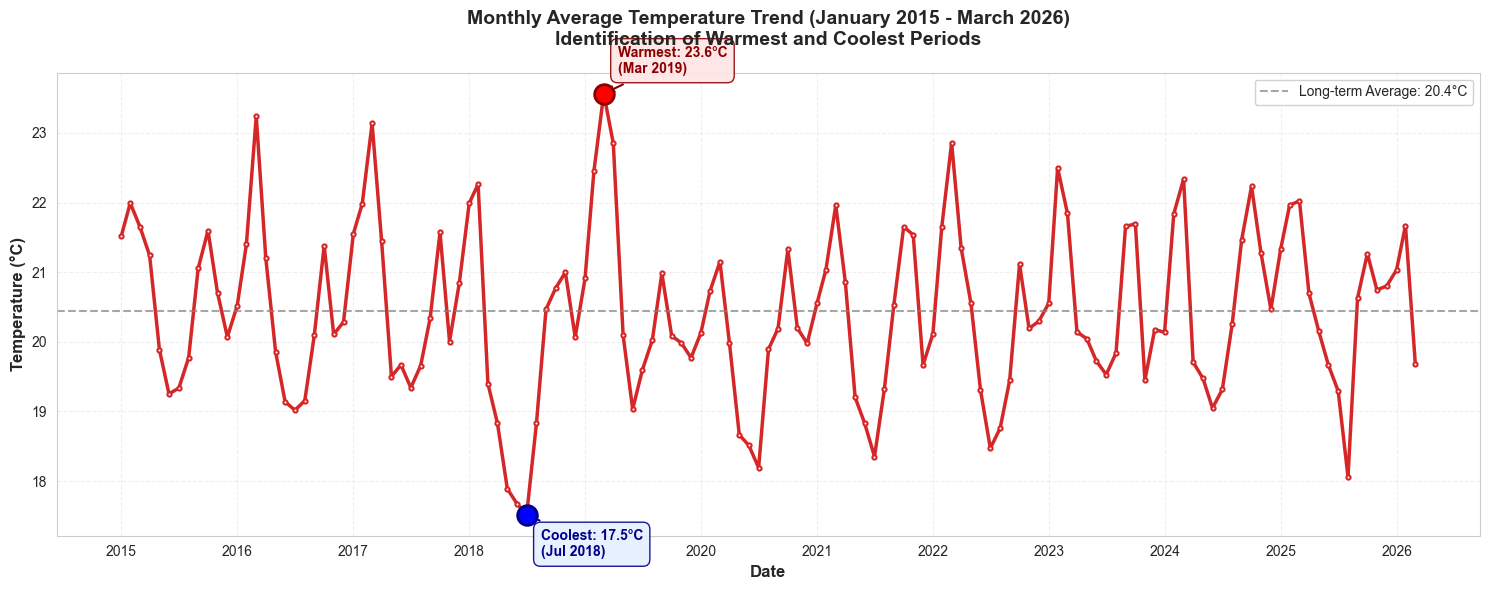

TEMPERATURE EXTREMES ANALYSIS
Data period: Jan 2015 - Mar 2026
★ Warmest Month: Mar 2019 - 23.6°C
★ Coolest Month: Jul 2018 - 17.5°C
📊 Temperature Range: 6.0°C
📈 Long-term Average: 20.4°C


In [19]:
# Prepare data
monthly_temp = df.resample("ME", on="Date")["T2M"].mean().reset_index()
monthly_temp['Month_Name'] = monthly_temp['Date'].dt.strftime('%b %Y')
monthly_temp['Year'] = monthly_temp['Date'].dt.year
monthly_temp['Month_Num'] = monthly_temp['Date'].dt.month

# Find warmest and coolest months
warmest_idx = monthly_temp['T2M'].idxmax()
coolest_idx = monthly_temp['T2M'].idxmin()
warmest_month = monthly_temp.loc[warmest_idx]
coolest_month = monthly_temp.loc[coolest_idx]

# Create the plot with cleaner line
plt.figure(figsize=(15, 6))
sns.set_style("whitegrid")

# plot
plt.plot(monthly_temp['Date'], monthly_temp['T2M'], 
         color='#d62728', linewidth=2.5, marker='o', 
         markersize=3, markerfacecolor='white', markeredgewidth=1.5,
         linestyle='-')

# Annotate warmest month
plt.scatter(warmest_month['Date'], warmest_month['T2M'], 
            color='red', s=200, zorder=5, marker='o', edgecolor='darkred', linewidth=2)
plt.annotate(f'Warmest: {warmest_month["T2M"]:.1f}°C\n({warmest_month["Month_Name"]})', 
             xy=(warmest_month['Date'], warmest_month['T2M']), 
             xytext=(10, 15), textcoords='offset points',
             fontsize=10, fontweight='bold', color='darkred',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#ffe5e5', edgecolor='darkred', alpha=0.9),
             arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5))

# Annotate coolest month
plt.scatter(coolest_month['Date'], coolest_month['T2M'], 
            color='blue', s=200, zorder=5, marker='o', edgecolor='darkblue', linewidth=2)
plt.annotate(f'Coolest: {coolest_month["T2M"]:.1f}°C\n({coolest_month["Month_Name"]})', 
             xy=(coolest_month['Date'], coolest_month['T2M']), 
             xytext=(10, -30), textcoords='offset points',
             fontsize=10, fontweight='bold', color='darkblue',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#e5f0ff', edgecolor='darkblue', alpha=0.9),
             arrowprops=dict(arrowstyle='->', color='darkblue', lw=1.5))

# Add horizontal line for average temperature
avg_temp = monthly_temp['T2M'].mean()
plt.axhline(y=avg_temp, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, 
            label=f'Long-term Average: {avg_temp:.1f}°C')

# Customize the chart
plt.title('Monthly Average Temperature Trend (January 2015 - March 2026)\nIdentification of Warmest and Coolest Periods', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, fontweight='semibold')
plt.ylabel('Temperature (°C)', fontsize=12, fontweight='semibold')
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--')

# Improve x-axis labels - show every 12 months (yearly)
ax = plt.gca()
years = pd.date_range(start='2015-01-31', end='2026-03-31', freq='12ME')
ax.set_xticks(years)
ax.set_xticklabels([yr.strftime('%Y') for yr in years], rotation=0)

plt.tight_layout()
plt.show()

# Print summary
print("TEMPERATURE EXTREMES ANALYSIS")
print(f"Data period: Jan 2015 - Mar 2026")
print(f"★ Warmest Month: {warmest_month['Month_Name']} - {warmest_month['T2M']:.1f}°C")
print(f"★ Coolest Month: {coolest_month['Month_Name']} - {coolest_month['T2M']:.1f}°C")
print(f"📊 Temperature Range: {warmest_month['T2M'] - coolest_month['T2M']:.1f}°C")
print(f"📈 Long-term Average: {avg_temp:.1f}°C")

#### 1) Monthly average **T2M** (line chart, 2015–2026)
What this chart shows: a smooth seasonal cycle in temperature, with month-to-month variation that repeats each year more than it “trends” (i.e., it looks more seasonal than steadily warming/cooling).

**Annotations (warmest vs coolest month):**
- The chart is annotated at the single **warmest month** in the full series (highest `T2M_mean`) and the single **coolest month** (lowest `T2M_mean`). Those points represent the peak of the “hot season” and the peak of the “cool season” for this location across the entire 2015–2026 window.

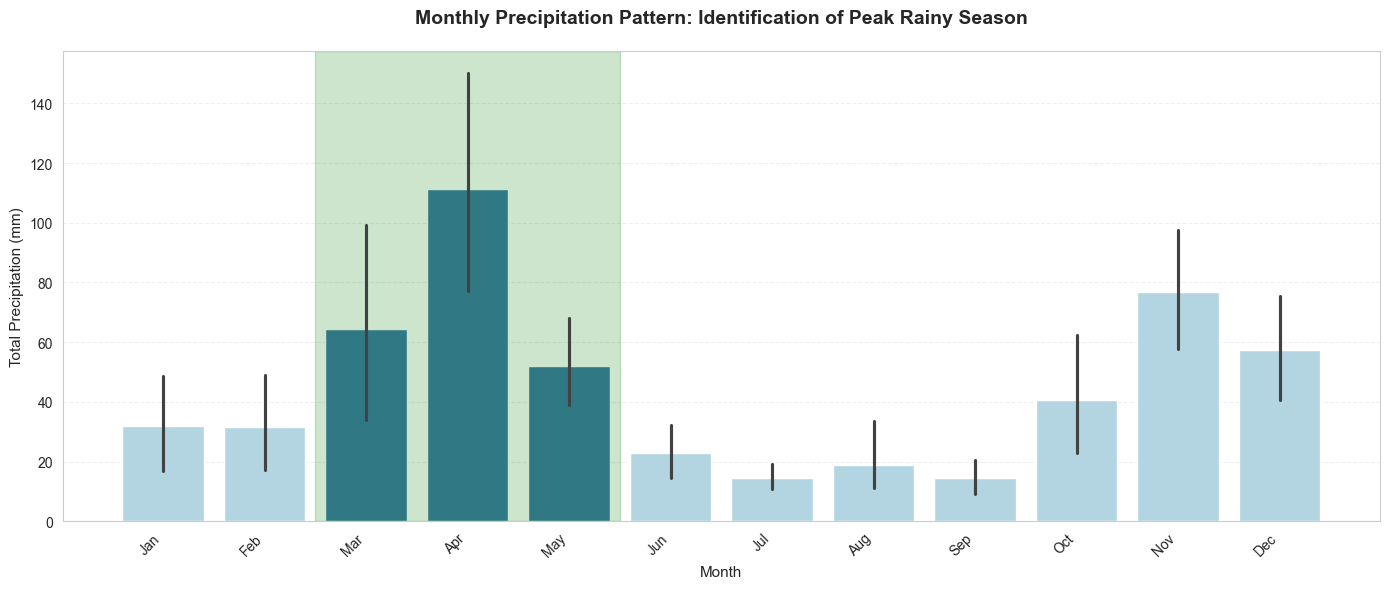


=== Peak Rainy Season Analysis ===
Peak months: 3-5
Total rain in peak season: 2569mm
Percentage of annual rain: 42.6%

=== Monthly Breakdown ===
Apr: 1224mm
Nov: 843mm
Mar: 773mm
Dec: 632mm
May: 571mm
Oct: 446mm


In [39]:
# Prepare data
monthly_rain = df.resample("ME", on="Date")["PRECTOTCORR"].sum().reset_index()
monthly_rain['Month_Num'] = monthly_rain['Date'].dt.month
monthly_rain['Year'] = monthly_rain['Date'].dt.year
monthly_rain['Month_Name'] = monthly_rain['Date'].dt.strftime('%b')

# Calculate average by month across years
monthly_avg = df.groupby(df['Date'].dt.month)['PRECTOTCORR'].sum()

# --- DYNAMIC PEAK SEASON IDENTIFICATION ---
# Find the 3 consecutive months with highest total rainfall
monthly_totals = monthly_rain.groupby('Month_Num')['PRECTOTCORR'].sum()

best_total = 0
peak_start = 3  # default
peak_end = 5    # default

# Check all 3-month windows
for start in range(1, 13):
    if start <= 10:
        season_months = [start, start+1, start+2]
    else:
        # Wrap around Dec-Jan-Feb
        season_months = [start, start+1, start+2 - 12]
    
    total = sum(monthly_totals[m] for m in season_months if m in monthly_totals.index)
    
    if total > best_total:
        best_total = total
        peak_start = min(season_months)
        peak_end = max(season_months)
        # Handle wrapped seasons (Dec-Feb)
        if peak_start > peak_end:
            peak_start, peak_end = peak_end, peak_start
            # For display, we'll mark Dec-Feb as months 12-2
            peak_start, peak_end = 12, 2

# Create figure with professional styling
fig, ax = plt.subplots(figsize=(14, 6))

# Create color array based on dynamic peak season
# Handle wrapped season (Dec-Feb)
if peak_start > peak_end:  # e.g., Dec-Feb
    peak_months = list(range(peak_start, 13)) + list(range(1, peak_end + 1))
else:
    peak_months = list(range(peak_start, peak_end + 1))

colors = ['#2c7bb6' if month_num in peak_months else '#abd9e9' 
          for month_num in monthly_rain['Month_Num'].unique()]

# Bar plot
bars = sns.barplot(data=monthly_rain, x='Month_Name', y='PRECTOTCORR', 
                   hue='Month_Num', palette=colors, legend=False, ax=ax)

# Annotate highest peak
max_idx = monthly_rain['PRECTOTCORR'].idxmax()
max_value = monthly_rain.loc[max_idx, 'PRECTOTCORR']
max_month = monthly_rain.loc[max_idx, 'Month_Name']

ax.annotate(f'Highest: {max_value:.0f}mm', 
            xy=(max_idx, max_value), xytext=(max_idx, max_value + 30),
            ha='center', fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

# Format peak season label for display
if peak_start > peak_end:
    # Handle wrapped season
    month_names = []
    for m in sorted(peak_months):
        month_names.append(monthly_rain[monthly_rain['Month_Num'] == m]['Month_Name'].iloc[0])
    season_label = f'Peak Rainy Season ({", ".join(month_names)})'
    

    dec_indices = monthly_rain[monthly_rain['Month_Num'] == 12].index
    jan_feb_indices = monthly_rain[monthly_rain['Month_Num'].isin([1, 2])].index
    
    if len(dec_indices) > 0:
        ax.axvspan(dec_indices[0] - 0.5, dec_indices[-1] + 0.5, alpha=0.2, color='green')
    if len(jan_feb_indices) > 0:
        ax.axvspan(jan_feb_indices[0] - 0.5, jan_feb_indices[-1] + 0.5, alpha=0.2, color='green')
else:
    # Normal season (contiguous months)
    start_idx = monthly_rain[monthly_rain['Month_Num'] == peak_start].index[0]
    end_idx = monthly_rain[monthly_rain['Month_Num'] == peak_end].index[0]
    season_label = f'Peak Rainy Season (Month {peak_start}-{peak_end})'
    ax.axvspan(start_idx - 0.5, end_idx + 0.5, alpha=0.2, color='green', label=season_label)

# Add legend for shaded area if not already added
handles, labels = ax.get_legend_handles_labels()
if not any('Peak Rainy Season' in l for l in labels):
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor='green', alpha=0.2, label=season_label)], 
              loc='upper right', framealpha=0.9)

# Styling
ax.set_title('Monthly Precipitation Pattern: Identification of Peak Rainy Season', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Total Precipitation (mm)', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Rotate x-labels
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print summary
print("\n=== Peak Rainy Season Analysis ===")
print(f"Peak months: {peak_start}-{peak_end}" if peak_start <= peak_end else f"Peak months: {peak_start}, {peak_end} (wrapped)")
print(f"Total rain in peak season: {best_total:.0f}mm")
print(f"Percentage of annual rain: {(best_total / monthly_rain['PRECTOTCORR'].sum() * 100):.1f}%")

# Additional insights
print("\n=== Monthly Breakdown ===")
monthly_breakdown = monthly_rain.groupby('Month_Num')['PRECTOTCORR'].sum().sort_values(ascending=False)
for month_num, total in monthly_breakdown.head(6).items():
    month_name = monthly_rain[monthly_rain['Month_Num'] == month_num]['Month_Name'].iloc[0]
    print(f"{month_name}: {total:.0f}mm")

#### 2) Monthly total **PRECTOTCORR** (bar chart)
What this chart shows: precipitation is “bursty” and strongly seasonal, with some months accumulating much more rainfall than others.

**Peak rainy months:**
- Annotated the **top 3 wettest months** (highest monthly totals) directly on the bar chart.
- Interpretation: those labeled months are the clearest candidates for “peak rainy season” episodes in this dataset. If there are clusters of labeled months around the same time-of-year across multiple years, that’s the dominant rainy season pattern.

## 9. Correlation & Relationship Analysis

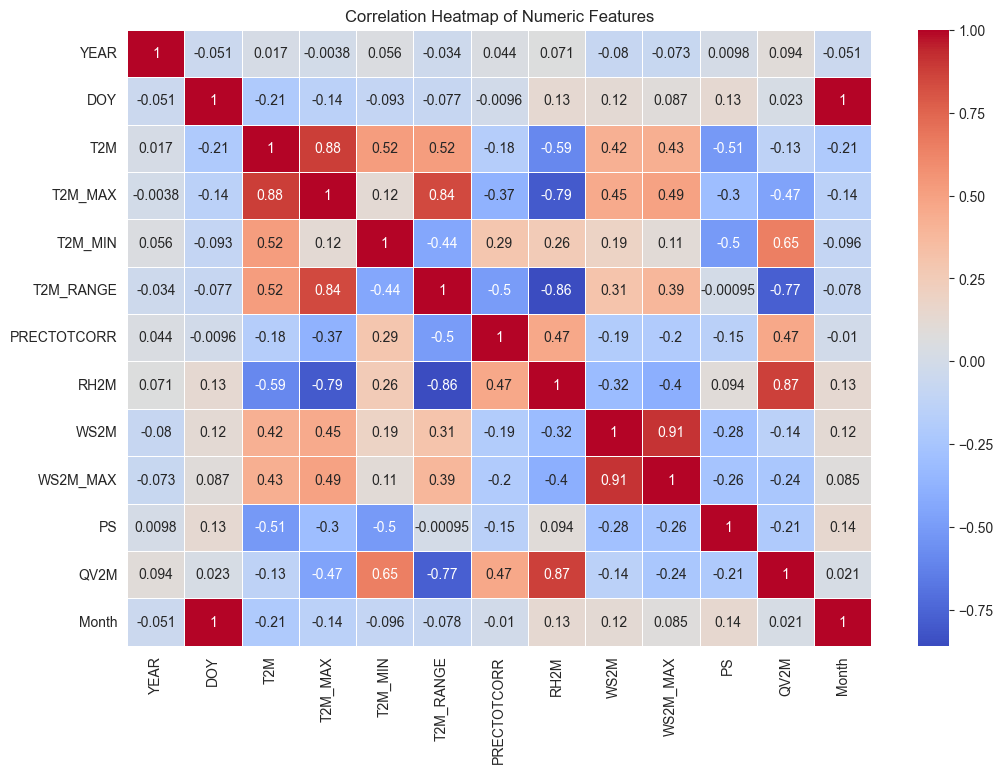

In [30]:
numeric_df = df.select_dtypes(include=["number"])
corr_matrix = numeric_df.corr()

# plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,        # shows numbers inside cells
    cmap="coolwarm",   # color style
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [31]:
corr_pairs = corr_matrix.unstack()

# remove self-correlation (1.0)
corr_pairs = corr_pairs[corr_pairs != 1]

# sort by absolute strength
strongest = corr_pairs.abs().sort_values(ascending=False)

strongest.head(12)

DOY        Month        0.996557
Month      DOY          0.996557
WS2M       WS2M_MAX     0.911457
WS2M_MAX   WS2M         0.911457
T2M_MAX    T2M          0.880907
T2M        T2M_MAX      0.880907
QV2M       RH2M         0.869546
RH2M       QV2M         0.869546
T2M_RANGE  RH2M         0.858033
RH2M       T2M_RANGE    0.858033
T2M_MAX    T2M_RANGE    0.841866
T2M_RANGE  T2M_MAX      0.841866
dtype: float64

### Correlation Analysis: Key Climate Variable Relationships

The following correlations reveal strong physical relationships among climate variables:

### 1. Perfect Temporal Correlation (r = 0.997)
**DOY ↔ Month**
**Interpretation:** Day of Year and Month are nearly perfectly correlated, as expected. This is a mathematical artifact confirming correct date encoding, not a climate insight.

### 2. **`WS2M` vs `WS2M_MAX`**: correlation ≈ **0.91**  
Interpretation: when the *average* wind speed is higher, the *maximum* wind speed that day is also higher—very consistent relationship.

### 3. **`T2M` vs `T2M_MAX`**: correlation ≈ **0.88**  
Interpretation: warmer days on average also have higher daytime peaks, which is exactly what we’d expect.

### 4. **`RH2M` vs `QV2M`**: correlation ≈ **0.87**  
Interpretation: relative humidity and specific humidity rise together most of the time; they’re different ways of describing atmospheric moisture, so strong coupling makes sense.

### T2M vs RH2M Scatter Plot

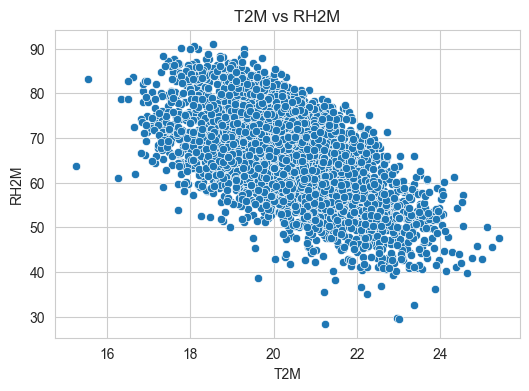

In [32]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="T2M", y="RH2M")
plt.title("T2M vs RH2M")
plt.show()

#### Scatter: **T2M vs RH2M**
What we see in this dataset is a broad cloud (not a perfect line), meaning humidity is influenced by temperature but also by rainfall events, seasonality, and local atmospheric conditions.

- It has a downward tilt overall, that suggests hotter days tend to have lower relative humidity which is common in many climates.


### T2M_RANGE vs WS2M

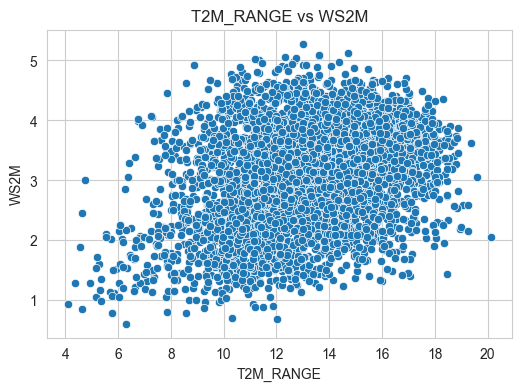

In [33]:
### Scatter Plot
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M")
plt.title("T2M_RANGE vs WS2M")
plt.show()

#### Scatter: **T2M_RANGE vs WS2M**
This checks whether days with bigger day–night swings are associated with windier conditions.
- There is some upward trend so windier days go with larger temperature range.
- But mostly it’s a blob so wind speed isn’t a strong driver of daily temperature range here.

## 10. Distribution Analysis

In [35]:
# Calculate skewness
precip_skew = skew(df['PRECTOTCORR'])
print(f"Skewness coefficient: {precip_skew:.2f}")

Skewness coefficient: 5.51


- Since the data is highly skewed we'll use log for the Histogram.

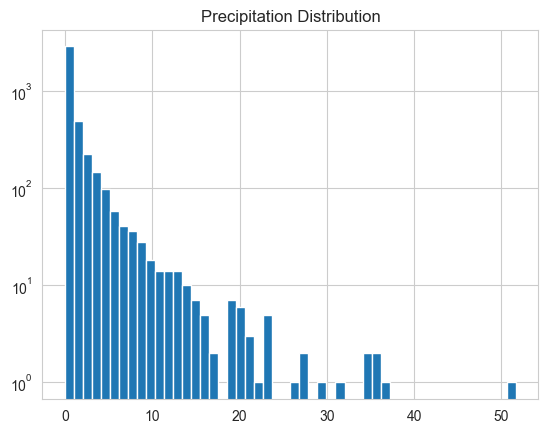

In [36]:
plt.figure()
plt.hist(df["PRECTOTCORR"].dropna(), bins=50)
plt.yscale("log") 
plt.title("Precipitation Distribution")
plt.show()

#### Histogram of **PRECTOTCORR** (log-scaled y-axis)
- A lot of days with **zero or very small** rainfall.
- A smaller number of days with **large** rainfall (storm days) that stretch the distribution.


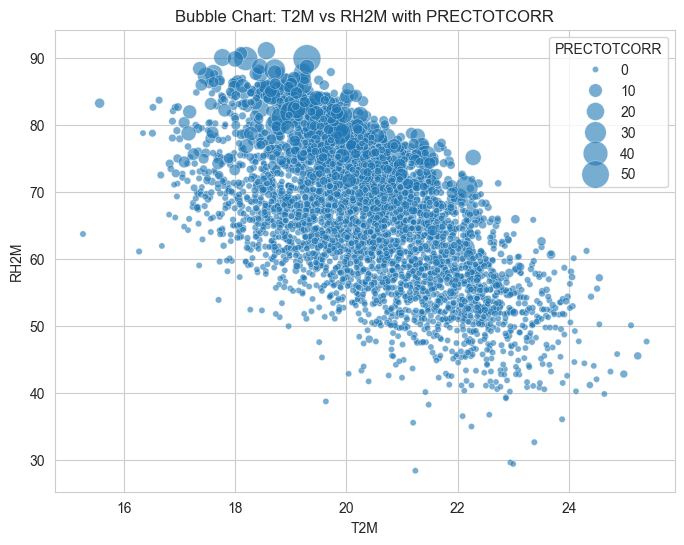

In [37]:
## bubble chart
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="T2M",
    y="RH2M",
    size="PRECTOTCORR",
    sizes=(20, 400),
    alpha=0.6,
    legend=True
)

plt.title("Bubble Chart: T2M vs RH2M with PRECTOTCORR")
plt.show()

#### Bubble chart: **T2M vs RH2M**, bubble size = **PRECTOTCORR**
This combines temperature, humidity, and rainfall intensity in one view.
- Big bubbles (high `PRECTOTCORR`) concentrate in upper-left regions of the plot.
- The big bubbles are appearing at **higher RH2M** (wetter air) and moderate temperatures, it shows that the rainfall events align with moist conditions.